#**Regression Analysis - Project**

# 0. IMPORTS


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import plotly.express as px
import plotly.graph_objects as go
from ipywidgets import interact, Dropdown
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. DATA LOADING & EXPLORATION

In [9]:
df = pd.read_csv('kc_house_data.csv')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


Understand the Dataset

In [10]:
df.info()
df.describe()

print('Number of unique values in each column:')
print(df.nunique())

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

 Data Cleaning

In [11]:
# Drop ID — not useful for prediction
print("ID is useless for prediction")
df = df.drop(['id'], axis=1)

# Parse date and extract year/month features
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df = df.drop(['date'], axis=1)

print('\nData types after converting date column:')
df.info()

print('Missing values in each column:')
df.isnull().sum()

ID is useless for prediction

Data types after converting date column:
<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21613 non-null  float64
 1   bedrooms       21613 non-null  int64  
 2   bathrooms      21613 non-null  float64
 3   sqft_living    21613 non-null  int64  
 4   sqft_lot       21613 non-null  int64  
 5   floors         21613 non-null  float64
 6   waterfront     21613 non-null  int64  
 7   view           21613 non-null  int64  
 8   condition      21613 non-null  int64  
 9   grade          21613 non-null  int64  
 10  sqft_above     21613 non-null  int64  
 11  sqft_basement  21613 non-null  int64  
 12  yr_built       21613 non-null  int64  
 13  yr_renovated   21613 non-null  int64  
 14  zipcode        21613 non-null  int64  
 15  lat            21613 non-null  float64
 16  long           21613 non-null  flo

price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
year             0
month            0
dtype: int64

Feature Engineering

In [12]:
# Total living area
df['total_sqft'] = df['sqft_living'] + df['sqft_basement']

# Age of the house at time of sale
df['house_age'] = df['year'] - df['yr_built']

# Binary flag: was the house ever renovated?
df['was_renovated'] = (df['yr_renovated'] != 0).astype(int)

# Years since last renovation (0 if never renovated)
df['age_since_renovation'] = df.apply(
    lambda row: row['year'] - row['yr_renovated'] if row['was_renovated'] == 1 else 0,
    axis=1
)

# Drop raw year columns now that features are extracted
df = df.drop(['yr_built', 'yr_renovated'], axis=1)

# Mark waterfront as categorical
df['waterfront'] = df['waterfront'].astype('category')

print('New features created and data types updated:')
df.info()
df.head()

New features created and data types updated:
<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   price                 21613 non-null  float64 
 1   bedrooms              21613 non-null  int64   
 2   bathrooms             21613 non-null  float64 
 3   sqft_living           21613 non-null  int64   
 4   sqft_lot              21613 non-null  int64   
 5   floors                21613 non-null  float64 
 6   waterfront            21613 non-null  category
 7   view                  21613 non-null  int64   
 8   condition             21613 non-null  int64   
 9   grade                 21613 non-null  int64   
 10  sqft_above            21613 non-null  int64   
 11  sqft_basement         21613 non-null  int64   
 12  zipcode               21613 non-null  int64   
 13  lat                   21613 non-null  float64 
 14  long                

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,lat,long,sqft_living15,sqft_lot15,year,month,total_sqft,house_age,was_renovated,age_since_renovation
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,47.5112,-122.257,1340,5650,2014,10,1180,59,0,0.0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,47.7210,-122.319,1690,7639,2014,12,2970,63,1,23.0
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,47.7379,-122.233,2720,8062,2015,2,770,82,0,0.0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,47.5208,-122.393,1360,5000,2014,12,2870,49,0,0.0
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,47.6168,-122.045,1800,7503,2015,2,1680,28,0,0.0


#2. TRAIN / TEST SPLIT

In [13]:
X = df.drop(['price'], axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#3. OUTLIER DETECTION & HANDLING

Visualize target distribution before clipping

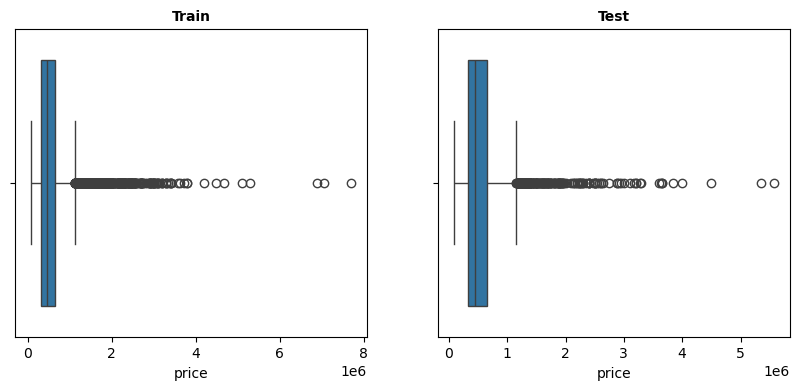

In [14]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=y_train)
plt.title('Train', fontsize=10, fontweight='bold')

plt.subplot(1, 2, 2)
sns.boxplot(x=y_test)
plt.title('Test', fontsize=10, fontweight='bold')
plt.show()

Clip target outliers using IQR method

In [15]:
print("Handling outliers in target using IQR Method\n")

Q1 = y_train.quantile(0.01)
Q3 = y_train.quantile(0.99)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

y_train = y_train.clip(lower, upper)
y_test  = y_test.clip(lower, upper)

print("Done handling outliers")
print("Final dataset shape:", y_train.shape)

Handling outliers in target using IQR Method

Done handling outliers
Final dataset shape: (17290,)


Visualize target distribution after clipping

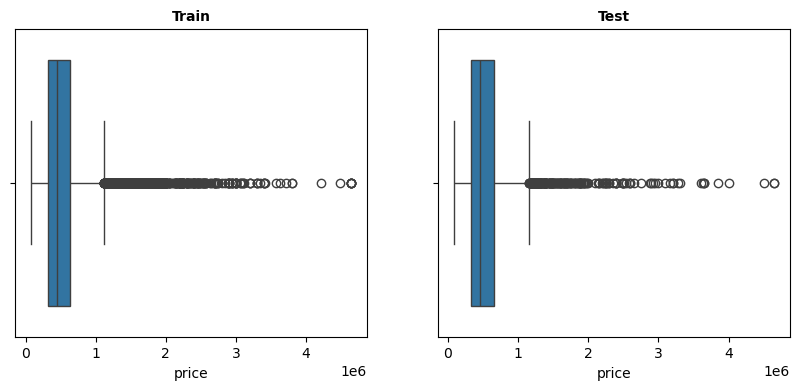

In [16]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=y_train)
plt.title('Train', fontsize=10, fontweight='bold')

plt.subplot(1, 2, 2)
sns.boxplot(x=y_test)
plt.title('Test', fontsize=10, fontweight='bold')
plt.show()

# 4. CORRELATION ANALYSIS  (before scaling)

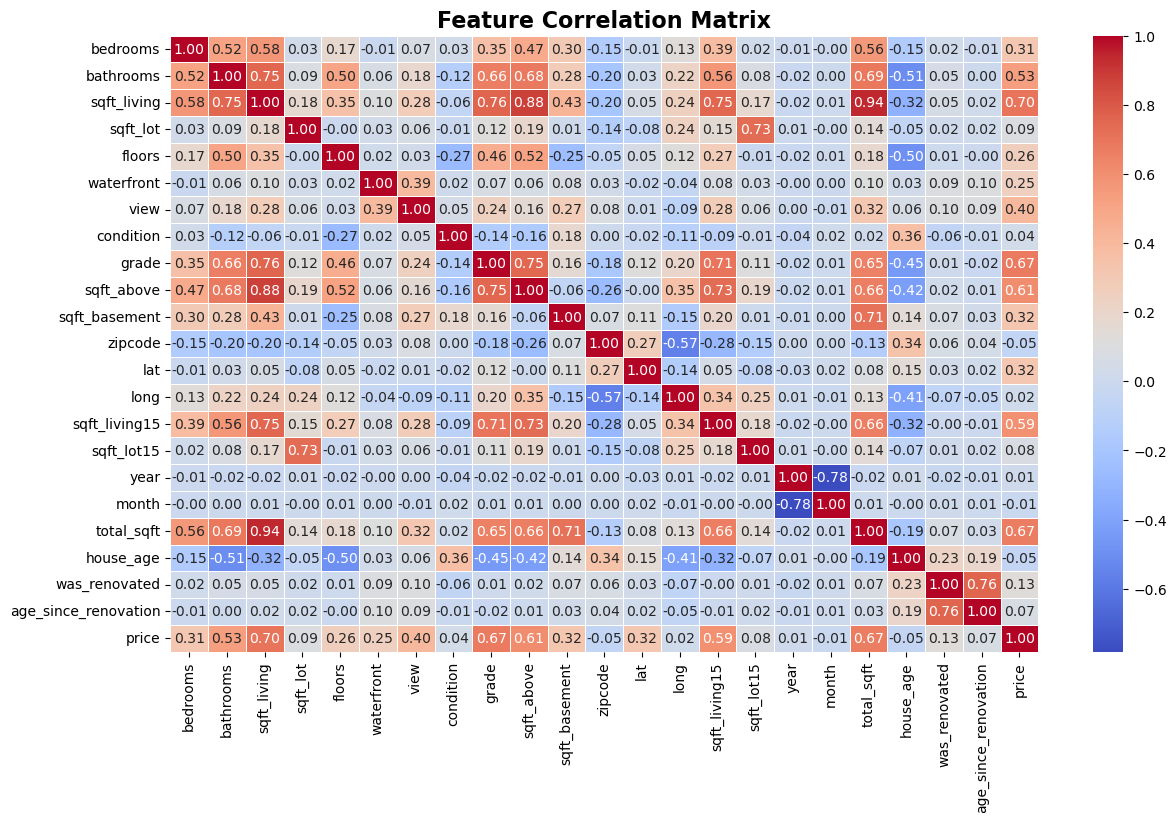

In [17]:
y_train = pd.Series(y_train, name='price')

correlation_matrix = pd.concat([X_train, y_train], axis=1).corr()

plt.figure(figsize=(14, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Matrix", fontsize=16, fontweight='bold')
plt.show()

Clip feature outliers using IQR method

In [18]:
print("Detecting outliers in Features BEFORE clipping using IQR method")
num_cols = X_train.select_dtypes(include=[np.number]).columns

for col in num_cols:
    Q1 = X_train[col].quantile(0.01)
    Q3 = X_train[col].quantile(0.99)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers_count = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    print(f"the number of Outliers in {col}: {outliers_count}")

print("\nHandle outliers in features using IQR clipping:\n")
for col in num_cols:
    Q1 = X_train[col].quantile(0.01)
    Q3 = X_train[col].quantile(0.99)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col]  = X_test[col].clip(lower, upper)

print("Done handling outliers")
print("Final dataset shape:", X_train.shape)

print("Detecting outliers in Features AFTER clipping")
num_cols = X_train.select_dtypes(include=[np.number]).columns

for col in num_cols:
    Q1 = X_train[col].quantile(0.01)
    Q3 = X_train[col].quantile(0.99)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers_count = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    print(f"the number of Outliers in {col}: {outliers_count}")

Detecting outliers in Features BEFORE clipping using IQR method
the number of Outliers in bedrooms: 1
the number of Outliers in bathrooms: 0
the number of Outliers in sqft_living: 1
the number of Outliers in sqft_lot: 10
the number of Outliers in floors: 0
the number of Outliers in view: 0
the number of Outliers in condition: 0
the number of Outliers in grade: 0
the number of Outliers in sqft_above: 0
the number of Outliers in sqft_basement: 1
the number of Outliers in zipcode: 0
the number of Outliers in lat: 0
the number of Outliers in long: 0
the number of Outliers in sqft_living15: 0
the number of Outliers in sqft_lot15: 5
the number of Outliers in year: 0
the number of Outliers in month: 0
the number of Outliers in total_sqft: 2
the number of Outliers in house_age: 0
the number of Outliers in was_renovated: 0
the number of Outliers in age_since_renovation: 6

Handle outliers in features using IQR clipping:

Done handling outliers
Final dataset shape: (17290, 22)
Detecting outliers

# 5. ENCODING & SCALING

One-Hot Encode 'waterfront'

In [19]:
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_encoded = enc.fit_transform(X_train[['waterfront']])
X_test_encoded  = enc.transform(X_test[['waterfront']])

train_ohe = pd.DataFrame(
    X_train_encoded,
    columns=enc.get_feature_names_out(['waterfront']),
    index=X_train.index
)
test_ohe = pd.DataFrame(
    X_test_encoded,
    columns=enc.get_feature_names_out(['waterfront']),
    index=X_test.index
)

X_train_final = pd.concat([X_train.drop(['waterfront'], axis=1), train_ohe], axis=1)
X_test_final  = pd.concat([X_test.drop(['waterfront'], axis=1),  test_ohe],  axis=1)

X_train_final.info()

<class 'pandas.DataFrame'>
Index: 17290 entries, 6325 to 15795
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   bedrooms              17290 non-null  int64  
 1   bathrooms             17290 non-null  float64
 2   sqft_living           17290 non-null  float64
 3   sqft_lot              17290 non-null  float64
 4   floors                17290 non-null  float64
 5   view                  17290 non-null  int64  
 6   condition             17290 non-null  int64  
 7   grade                 17290 non-null  int64  
 8   sqft_above            17290 non-null  int64  
 9   sqft_basement         17290 non-null  int64  
 10  zipcode               17290 non-null  int64  
 11  lat                   17290 non-null  float64
 12  long                  17290 non-null  float64
 13  sqft_living15         17290 non-null  int64  
 14  sqft_lot15            17290 non-null  float64
 15  year                  17290 non-

Standard Scale numeric features

In [20]:
scaler_x = StandardScaler()
X_train_final[num_cols] = scaler_x.fit_transform(X_train_final[num_cols])
X_test_final[num_cols]  = scaler_x.transform(X_test_final[num_cols])

print("\nAfter scaling:")
print("1. Features:")
print(X_train_final.head())
print("++----------------------------++")


After scaling:
1. Features:
       bedrooms  bathrooms  sqft_living  sqft_lot    floors      view  \
6325  -0.404957  -0.474451    -0.324060 -0.043217 -0.919600 -0.305917   
13473 -1.508631  -1.452583    -1.184259 -0.313063 -0.919600 -0.305917   
17614 -0.404957  -1.452583    -1.096033 -0.204320  0.001545 -0.305917   
16970 -0.404957   0.177636     0.017814 -0.203918 -0.919600 -0.305917   
20868 -1.508631   0.503680    -0.367070 -0.378004  0.922690 -0.305917   

       condition     grade  sqft_above  sqft_basement  ...  sqft_living15  \
6325    0.909073  1.150243   -0.007257      -0.656793  ...       1.126073   
13473  -0.625426 -1.413156   -1.200048      -0.200516  ...      -1.046523   
17614  -0.625426 -1.413156   -0.968792      -0.451468  ...      -1.193320   
16970   0.909073 -0.558690   -0.615824       1.191126  ...      -0.268498   
20868  -0.625426  0.295777   -0.413779       0.016215  ...       0.157213   

       sqft_lot15      year     month  total_sqft  house_age  was_ren

# 6. EXPLORATORY VISUALIZATIONS


Scatter plot: sqft_living vs price with regression line

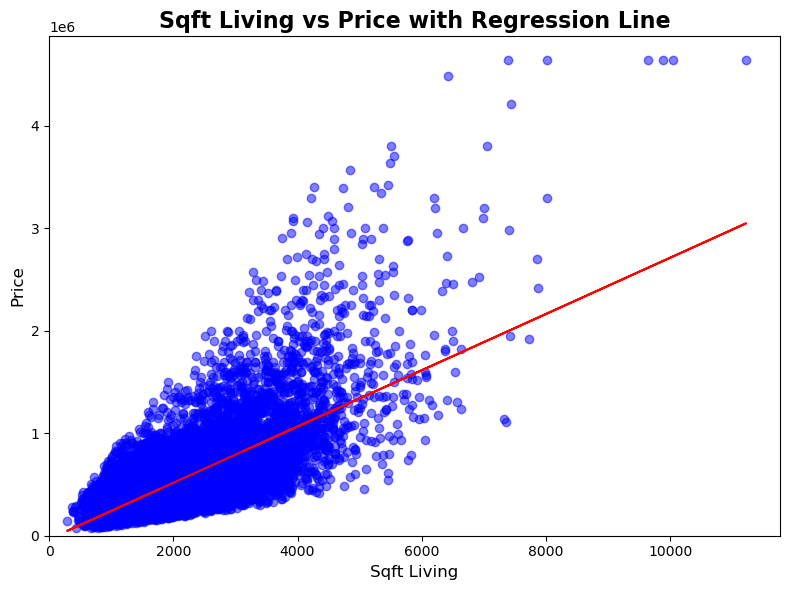

In [21]:
x = X_train["sqft_living"]
y = y_train

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.5, color="blue")

m, b = np.polyfit(x, y, 1)
plt.plot(x, m * x + b, color="red")

plt.xlim(0)
plt.ylim(0)
plt.xlabel("Sqft Living", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.title("Sqft Living vs Price with Regression Line", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Price distribution histogram

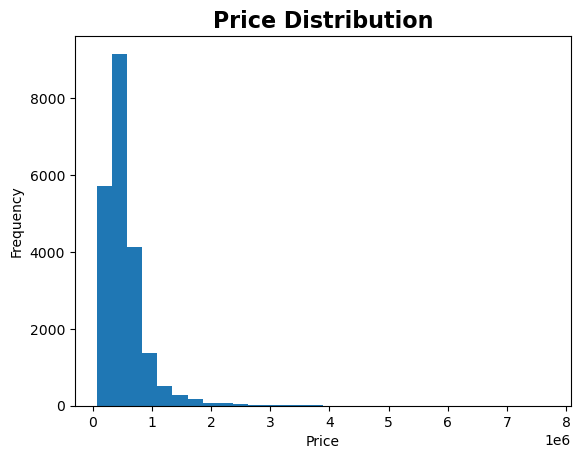

In [22]:
plt.hist(df['price'], bins=30)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Price Distribution', fontsize=16, fontweight='bold')
plt.show()

Average price by number of bedrooms

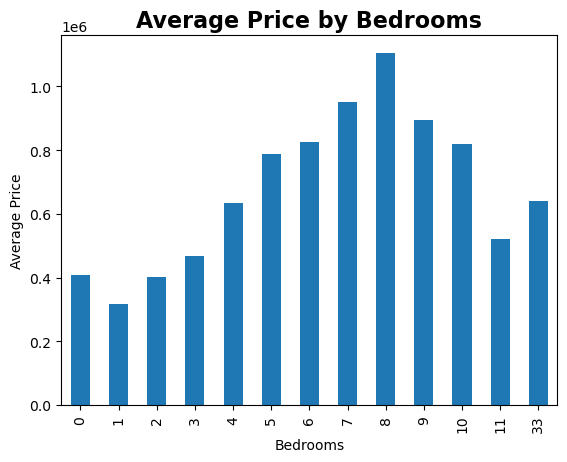

In [23]:
plt.figure()
df.groupby('bedrooms')['price'].mean().plot(kind='bar')
plt.xlabel('Bedrooms')
plt.ylabel('Average Price')
plt.title('Average Price by Bedrooms', fontsize=16, fontweight='bold')
plt.show()

 Price density KDE plot

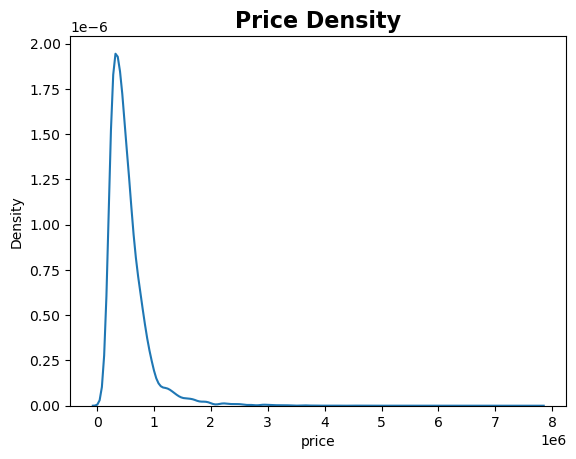

In [24]:
plt.figure()
sns.kdeplot(df['price'])
plt.title('Price Density', fontsize=16, fontweight='bold')
plt.show()

# 7. MODELING

The modeling stage is divided into three complementary views:

1.   Numerical View   — manual OLS calculation
2. Statistical View — inference & significance testing
3. Machine View     — gradient descent (plain, Ridge, Lasso)

1.  Numerical View (From Scratch)

Manual OLS calculation using a single predictor (sqft_living).

In [25]:
X_num = X_train_final['sqft_living'].values
y_num = y_train.values

x_mean = np.mean(X_num)
y_mean = np.mean(y_num)

# B1 = Σ(x - x̄)(y - ȳ) / Σ(x - x̄)²
numerator   = np.sum((X_num - x_mean) * (y_num - y_mean))
denominator = np.sum((X_num - x_mean) ** 2)

b1 = numerator / denominator
b0 = y_mean - (b1 * x_mean)

print(f"Numerical View results:")
print(f"Intercept (B0): {b0:.4f}")
print(f"Slope     (B1): {b1:.4f}")

sample_sqft     = X_num[0]
predicted_price = b0 + b1 * sample_sqft
actual_price    = y_num[0]

print(f"\nExample Prediction:")
print(f"Sqft Living (scaled): {sample_sqft:.4f}")
print(f"Predicted Price:      {predicted_price:.2f}")
print(f"Actual Price         {actual_price:.2f}")

Numerical View results:
Intercept (B0): 537255.2369
Slope     (B1): 248853.1775

Example Prediction:
Sqft Living (scaled): -0.3241
Predicted Price:      456611.86
Actual Price         325000.00


2. Statistical View (From Scratch)

- Implements simple linear regression using the Normal Equation.
- Computes standard errors, t-statistics, and R² for interpretability.

In [26]:
class StatisticalLinearRegression:
    def __init__(self):
        self.B_0   = None
        self.B_1   = None
        self.MSE   = None
        self.R2    = None
        self.SE_B1 = None
        self.SE_B0 = None
        self.t_B1  = None
        self._n    = None
        self._SXX  = None

    def fit(self, X, y):
        X = np.array(X).flatten()
        y = np.array(y).flatten()

        x_bar = X.mean()
        y_bar = y.mean()

        SXX = np.sum(X**2) - len(X) * (x_bar**2)
        SXY = np.sum(X * y) - len(X) * x_bar * y_bar

        if SXX == 0:
            raise ValueError(
                "All X values are identical — the slope is undefined. "
                "Please check your feature column."
            )

        self.B_1 = SXY / SXX
        self.B_0 = y_bar - (self.B_1 * x_bar)

        y_hat = self.predict(X)
        e   = y - y_hat
        SSE = np.sum(e ** 2)
        SST = np.sum((y - y_bar) ** 2)

        self.MSE  = SSE / (len(X) - 2)
        self.R2   = 1 - SSE / SST if SST != 0 else 0.0

        self.SE_B1 = np.sqrt(self.MSE / SXX)
        self.SE_B0 = np.sqrt(self.MSE * (1 / len(X) + x_bar ** 2 / SXX))
        self.t_B1  = self.B_1 / self.SE_B1 if self.SE_B1 != 0 else np.inf

        self._n   = len(X)
        self._SXX = SXX

        return self

    def predict(self, X):
        if self.B_0 is None or self.B_1 is None:
            raise ValueError("The model has not been fitted yet.")
        X = np.array(X, dtype=float).flatten()
        return self.B_0 + self.B_1 * X

    def summary(self):
        if self.B_0 is None:
            print("Model has not been fitted yet.")
            return

        sep = "-" * 46
        print(sep)
        print("   Statistical Linear Regression — Summary")
        print(sep)
        print(f"  Intercept  (B0) : {self.B_0:>18.6f}")
        print(f"  Slope      (B1) : {self.B_1:>18.6f}")
        print(f"  SE(B0)          : {self.SE_B0:>18.6f}")
        print(f"  SE(B1)          : {self.SE_B1:>18.6f}")
        print(f"  t-stat  (B1=0)  : {self.t_B1:>18.6f}")
        print(f"  MSE             : {self.MSE:>18.6f}")
        print(f"  R²              : {self.R2:>18.6f}")
        print(f"  n               : {self._n:>18d}")
        print(sep)


stat_model = StatisticalLinearRegression()
stat_model.fit(X_train_final['sqft_living'], y_train)
stat_model.summary()

----------------------------------------------
   Statistical Linear Regression — Summary
----------------------------------------------
  Intercept  (B0) :      537255.236900
  Slope      (B1) :      248853.177520
  SE(B0)          :        1913.543374
  SE(B1)          :        1913.543374
  t-stat  (B1=0)  :         130.048360
  MSE             : 63309898140.420601
  R²              :           0.494511
  n               :              17290
----------------------------------------------


3. Machine View (From Scratch)

- Multiple Linear Regression trained with Gradient Descent.
- Supports optional Lasso and Ridge regularization.


3.1  Model Class

In [27]:
class multipleLinearRegressionGd:
    """Multiple Linear Regression via Gradient Descent (no regularization by default)."""

    def __init__(self):
        self.B_0 = None
        self.B   = None
        self.SSE = float('inf')
        self.MSE = None

    def fit(self, X, y, learning_rate=0.01, epochs=1000, tolerance=1e-6, lasso=0, ridge=0):
        X = np.atleast_2d(np.array(X, float))
        y = np.asarray(y, float).reshape(-1)

        self.n, self.k = X.shape
        self.X = X
        self.y = y

        self.B_0 = 0
        self.B   = np.zeros(self.k)

        for _ in range(epochs):
            y_hat = self.B_0 + self.X @ self.B
            error = y_hat - self.y

            new_sse = np.sum((self.y - (self.B_0 + self.X @ self.B)) ** 2)

            if self.SSE is not None and abs(new_sse - self.SSE) < tolerance:
                self.SSE = new_sse
                break
            self.SSE = new_sse

            dB_0 = (2 / self.n) * np.sum(error)
            dB   = (2 / self.n) * (self.X.T @ error)

            self.B_0 -= learning_rate * dB_0
            self.B   -= learning_rate * dB

            new_sse = np.sum((self.y - (self.B_0 + self.X @ self.B)) ** 2)

        self.MSE = self.SSE / self.n

    def predict(self, X):
        X = np.atleast_2d(np.array(X, float))
        return self.B_0 + X @ self.B

    def mse(self, y, y_pred):
        return np.mean((y - y_pred) ** 2)

    def r2(self, y, y_pred):
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        if ss_tot == 0:
            return 0.0
        return 1 - (ss_res / ss_tot)

3.2  Feature Selection via Correlation

<class 'pandas.DataFrame'>
Index: 17290 entries, 6325 to 15795
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   bedrooms              17290 non-null  float64
 1   bathrooms             17290 non-null  float64
 2   sqft_living           17290 non-null  float64
 3   sqft_lot              17290 non-null  float64
 4   floors                17290 non-null  float64
 5   view                  17290 non-null  float64
 6   condition             17290 non-null  float64
 7   grade                 17290 non-null  float64
 8   sqft_above            17290 non-null  float64
 9   sqft_basement         17290 non-null  float64
 10  zipcode               17290 non-null  float64
 11  lat                   17290 non-null  float64
 12  long                  17290 non-null  float64
 13  sqft_living15         17290 non-null  float64
 14  sqft_lot15            17290 non-null  float64
 15  year                  17290 non-

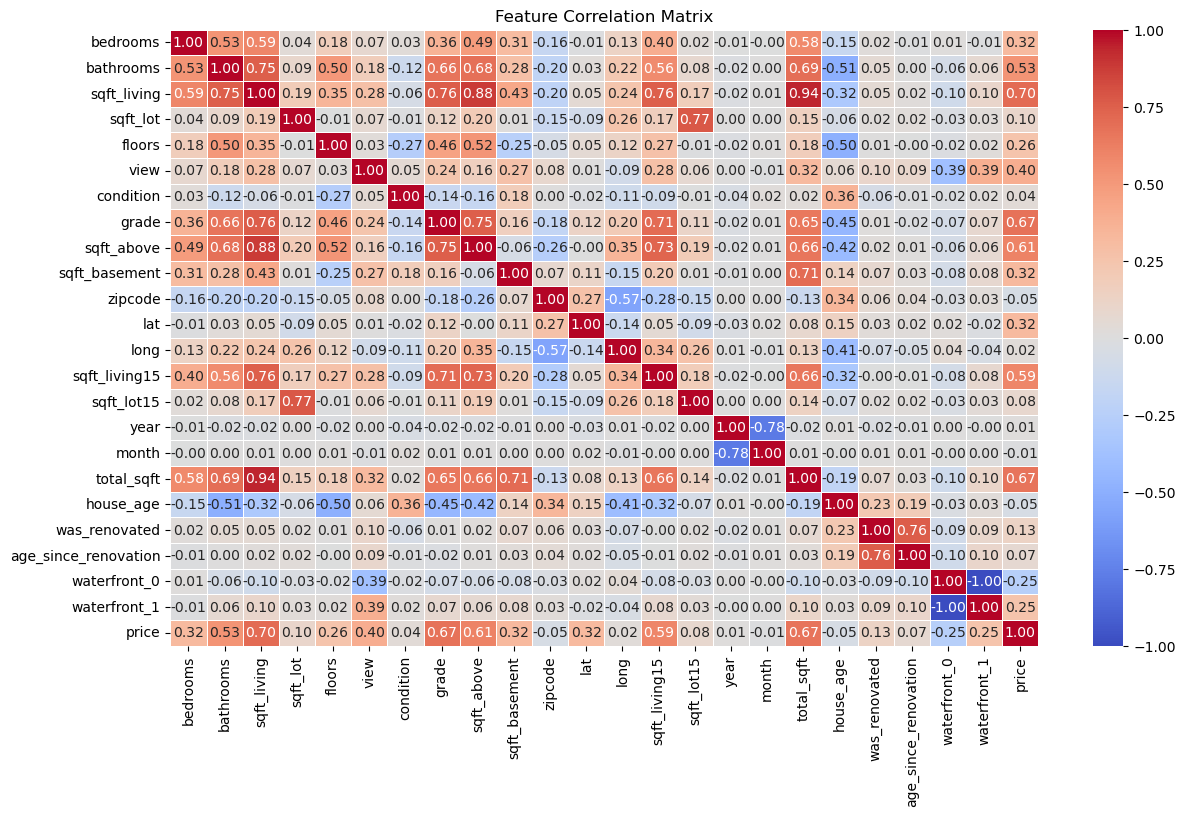

The feature with the strongest correlation to Price is: sqft_living
price                   1.000000
sqft_living             0.703215
grade                   0.673545
total_sqft              0.668694
sqft_above              0.605225
sqft_living15           0.590659
bathrooms               0.529250
view                    0.395028
sqft_basement           0.320504
bedrooms                0.319577
lat                     0.316663
floors                  0.257059
waterfront_1            0.251572
was_renovated           0.125953
sqft_lot                0.097066
sqft_lot15              0.079991
age_since_renovation    0.068863
condition               0.037097
long                    0.024438
year                    0.011961
month                  -0.014572
house_age              -0.050894
zipcode                -0.054220
waterfront_0           -0.251572
Name: price, dtype: float64
Index(['sqft_living', 'grade', 'total_sqft', 'sqft_above', 'sqft_living15',
       'bathrooms', 'view', 'sqft_ba

In [29]:
X_train_final.info()

y_train = pd.Series(y_train, name='price')

correlation_matrix = pd.concat([X_train_final, y_train], axis=1).corr()

plt.figure(figsize=(14, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

top_feature = correlation_matrix['price'].drop('price').abs().idxmax()
print(f"The feature with the strongest correlation to Price is: {top_feature}")

df_corr = X_train_final.copy()
df_corr['price'] = y_train.values

corr = df_corr.corr()['price'].sort_values(ascending=False)
print(corr)

# Keep features with |correlation| > 0.1
selected_features = corr[abs(corr) > 0.1].index.drop('price')
print(selected_features)
print(len(selected_features))

X_train_sel = X_train_final[selected_features]
X_test_sel  = X_test_final[selected_features]

3.3  Baseline Multiple Linear Regression

MSE: 48587970479.116554
R2: 0.6711890007600262


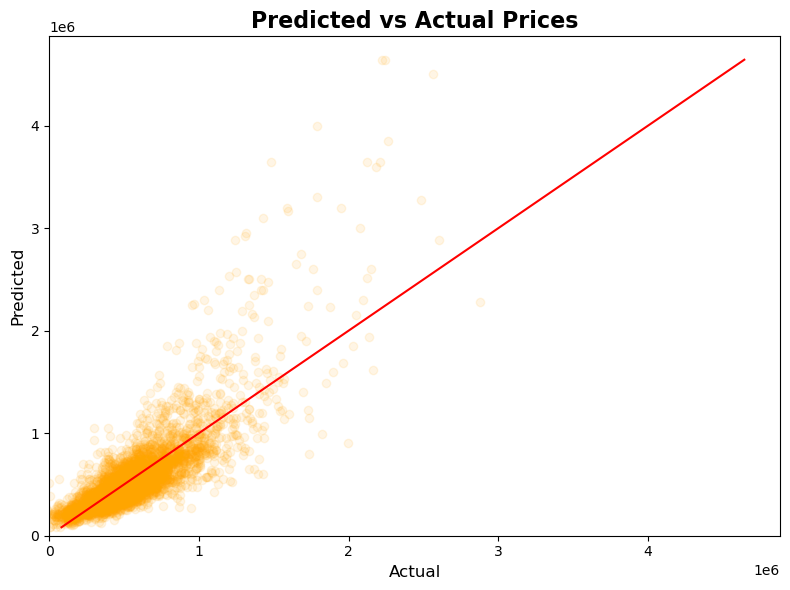

In [30]:
model = multipleLinearRegressionGd()
model.fit(X_train_sel, y_train, learning_rate=0.1, epochs=2000)

y_pred = model.predict(X_test_sel)

mse = model.mse(y_test, y_pred)
r2  = model.r2(y_test, y_pred)

print("MSE:", mse)
print("R2:",  r2)

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, y_test, alpha=0.1, color="orange")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.xlim(0)
plt.ylim(0)
plt.xlabel("Actual", fontsize=12)
plt.ylabel("Predicted", fontsize=12)
plt.title("Predicted vs Actual Prices", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#8. RIDGE REGRESSION

Encode and scale features for Ridge (uses numeric-only columns)

In [54]:
X_train = X_train.select_dtypes(include=[np.number])
X_test  = X_test.select_dtypes(include=[np.number])

mean = np.mean(X_train, axis=0)
std  = np.std(X_train,  axis=0)

X_train = (X_train - mean) / std
X_test  = (X_test  - mean) / std


class RidgeRegressionGD:
    """Ridge Regression trained with Gradient Descent (L2 regularization)."""

    def __init__(self, learning_rate=0.001, n_iterations=1000, lambda_param=0.001):
        self.lr           = learning_rate
        self.n_iterations = n_iterations
        self.lambda_param = lambda_param
        self.weights      = None
        self.bias         = None
        self.loss_history = []

    def fit(self, X, y):
        m, n = X.shape

        self.weights      = np.zeros(n)
        self.bias         = 0
        self.loss_history = []

        for _ in range(self.n_iterations):
            y_pred = np.dot(X, self.weights) + self.bias
            error  = y_pred - y

            dw = (1 / m) * np.dot(X.T, error) + (2 * self.lambda_param / m) * self.weights
            db = (1 / m) * np.sum(error)

            self.weights -= self.lr * dw
            self.bias    -= self.lr * db

            mse_loss      = np.mean(error ** 2)
            ridge_penalty = self.lambda_param * np.sum(self.weights ** 2)
            total_loss    = mse_loss + ridge_penalty
            self.loss_history.append(total_loss)

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

Train Ridge & evaluate

In [56]:
ridge_model = RidgeRegressionGD(learning_rate=0.001, n_iterations=5000, lambda_param=0.001)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)


def r2_score(y_true,y_pred_ridge):
    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_res   = np.sum((y_true - y_pred_ridge) ** 2)
    return 1 - (ss_res / ss_total)


def mean_squared_error(y_true, y_pred_ridge):
    return np.mean((y_true - y_pred_ridge) ** 2)


print("R2:",  r2_score(y_test, y_pred_ridge))
print("MSE:", mean_squared_error(y_test, y_pred_ridge))

R2: 0.688374129194324
MSE: 46048546570.01524


Tune Ridge lambda

In [60]:
lambdas   = [1, 0.1, 0.01, 0.001]
top_lambda = None
best_r2    = -float("inf")

ridge_model_for_best_lambda = RidgeRegressionGD(
    learning_rate=0.001, n_iterations=3000, lambda_param=lambdas[0]
)

for l in lambdas:
    model_l = RidgeRegressionGD(learning_rate=0.001, n_iterations=3000, lambda_param=l)
    model_l.fit(X_train, y_train)

    preds = model_l.predict(X_test)
    r2    = r2_score(y_test, preds)

    print(f"lambda = {l}, R2 = {r2}")

    if r2 > best_r2:
        best_r2    = r2
        top_lambda = l
        ridge_model_for_best_lambda = model_l

print("Best lambda:", top_lambda)
ridge_model = ridge_model_for_best_lambda

lambda = 1, R2 = 0.6774762562491149
lambda = 0.1, R2 = 0.6774815919186532
lambda = 0.01, R2 = 0.6774821254031501
lambda = 0.001, R2 = 0.6774821787507752
Best lambda: 0.001


Ridge convergence plot

In [58]:
import plotly.io as pio
pio.renderers.default = "browser"

fig_gd = px.line(
    x=range(len(ridge_model_for_best_lambda.loss_history)),
    y=ridge_model_for_best_lambda.loss_history,
    markers=True,
    labels={
        'x': 'Iterations (Epochs)',
        'y': 'Loss = MSE + λ × L2 Penalty'
    },
    title="Gradient Descent Convergence: Loss vs. Iterations<br>"
          "<sup>Ridge Regression (best λ selected on validation set)</sup>"
)
fig_gd.update_layout(height=600, width=1000, hovermode="x unified", template="plotly_white")
fig_gd.update_traces(line=dict(width=3, color="gray"))
fig_gd.show()


#9. LASSO REGRESSION



In [41]:
# Create a validation set from X_train_final for lambda tuning
np.random.seed(42)

if not isinstance(y_train, pd.Series):
    y_train = pd.Series(y_train, index=X_train_final.index)

indices   = np.random.permutation(len(X_train_final))
val_size  = int(0.2 * len(X_train_final))

val_indices        = indices[:val_size]
train_main_indices = indices[val_size:]

X_train_main  = X_train_final.iloc[train_main_indices].copy()
X_val         = X_train_final.iloc[val_indices].copy()
y_train_main  = y_train.iloc[train_main_indices].copy()
y_val         = y_train.iloc[val_indices].copy()

print("X_train_main shape:", X_train_main.shape)
print("X_val shape:",        X_val.shape)
print("y_train_main shape:", y_train_main.shape)
print("y_val shape:",        y_val.shape)

X_train_main_sel = X_train_main[selected_features].copy()
X_val_sel        = X_val[selected_features].copy()
X_test_sel       = X_test_final[selected_features].copy()

print("Number of selected features:", len(selected_features))
print(selected_features.tolist())


class LassoRegressionGD:
    """Lasso Regression trained with Gradient Descent (L1 regularization)."""

    def __init__(self):
        self.B_0          = None
        self.B            = None
        self.SSE          = None
        self.MSE          = None
        self.loss_history = []

    def fit(self, X, y, learning_rate=0.01, epochs=3000, tolerance=1e-6, lasso_lambda=0.1):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float).reshape(-1)

        self.n, self.k = X.shape
        self.B_0       = 0.0
        self.B         = np.zeros(self.k)
        self.loss_history = []

        previous_loss = float('inf')

        for epoch in range(epochs):
            y_hat  = self.B_0 + X @ self.B
            error  = y_hat - y

            dB_0 = (2 / self.n) * np.sum(error)
            dB   = (2 / self.n) * (X.T @ error)
            dB  += lasso_lambda * np.sign(self.B)

            self.B_0 -= learning_rate * dB_0
            self.B   -= learning_rate * dB

            sse        = np.sum((y - (self.B_0 + X @ self.B)) ** 2)
            l1_penalty = lasso_lambda * np.sum(np.abs(self.B))
            loss       = (sse / self.n) + l1_penalty
            self.loss_history.append(loss)

            if abs(previous_loss - loss) < tolerance:
                break
            previous_loss = loss

        self.SSE = sse
        self.MSE = sse / self.n

    def predict(self, X):
        X = np.array(X, dtype=float)
        return self.B_0 + X @ self.B

    def mse(self, y, y_pred):
        y      = np.array(y,      dtype=float).reshape(-1)
        y_pred = np.array(y_pred, dtype=float).reshape(-1)
        return np.mean((y - y_pred) ** 2)

    def r2(self, y, y_pred):
        y      = np.array(y,      dtype=float).reshape(-1)
        y_pred = np.array(y_pred, dtype=float).reshape(-1)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - (ss_res / ss_tot) if ss_tot != 0 else 0.0

X_train_main shape: (13832, 23)
X_val shape: (3458, 23)
y_train_main shape: (13832,)
y_val shape: (3458,)
Number of selected features: 14
['sqft_living', 'grade', 'total_sqft', 'sqft_above', 'sqft_living15', 'bathrooms', 'view', 'sqft_basement', 'bedrooms', 'lat', 'floors', 'waterfront_1', 'was_renovated', 'waterfront_0']


Tune Lasso lambda

In [42]:
lambda_values = [0.0001, 0.001, 0.01, 0.1, 1, 5, 10]

print("Candidate lambda values:")
print(lambda_values)

lasso_results = []

for lam in lambda_values:
    lasso_model = LassoRegressionGD()
    lasso_model.fit(
        X_train_main_sel, y_train_main,
        learning_rate=0.01, epochs=3000, tolerance=1e-6, lasso_lambda=lam
    )

    y_val_pred    = lasso_model.predict(X_val_sel)
    val_mse       = lasso_model.mse(y_val, y_val_pred)
    val_r2        = lasso_model.r2(y_val, y_val_pred)
    non_zero_count = np.sum(np.abs(lasso_model.B) > 1e-6)

    lasso_results.append({
        'lambda':                lam,
        'validation_mse':        val_mse,
        'validation_r2':         val_r2,
        'non_zero_coefficients': non_zero_count
    })

lasso_results_df = pd.DataFrame(lasso_results)
lasso_results_df

best_lambda = lasso_results_df.loc[lasso_results_df['validation_mse'].idxmin(), 'lambda']
print("Best lambda based on validation MSE:", best_lambda)

Candidate lambda values:
[0.0001, 0.001, 0.01, 0.1, 1, 5, 10]
Best lambda based on validation MSE: 0.0001


Train final Lasso model with best lambda

In [43]:
final_lasso_model = LassoRegressionGD()
final_lasso_model.fit(
    X_train_sel, y_train,
    learning_rate=0.01, epochs=3000, tolerance=1e-6, lasso_lambda=best_lambda
)

y_test_pred_lasso = final_lasso_model.predict(X_test_sel)

lasso_mse = final_lasso_model.mse(y_test, y_test_pred_lasso)
lasso_r2  = final_lasso_model.r2(y_test, y_test_pred_lasso)

print("Final Lasso Test MSE:", lasso_mse)
print("Final Lasso Test R2:",  lasso_r2)
print("Number of non-zero coefficients:", np.sum(np.abs(final_lasso_model.B) > 1e-6))

Final Lasso Test MSE: 50854940219.937935
Final Lasso Test R2: 0.655847660539886
Number of non-zero coefficients: 14


#10. MODEL COMPARISON

In [44]:
comparison_df = pd.DataFrame({
    'Model':                ['Baseline Multiple Linear Regression', 'Lasso Regression'],
    'MSE':                  [mse,    lasso_mse],
    'R2':                   [r2,     lasso_r2],
    'Number of Predictors': [len(selected_features), np.sum(np.abs(final_lasso_model.B) > 1e-6)]
})
comparison_df

,Model,MSE,R2,Number of Predictors
0,Baseline Multiple Linear Regression,4.858797e+10,0.676880,14
1,Lasso Regression,5.085494e+10,0.655848,14


Lambda tuning curve

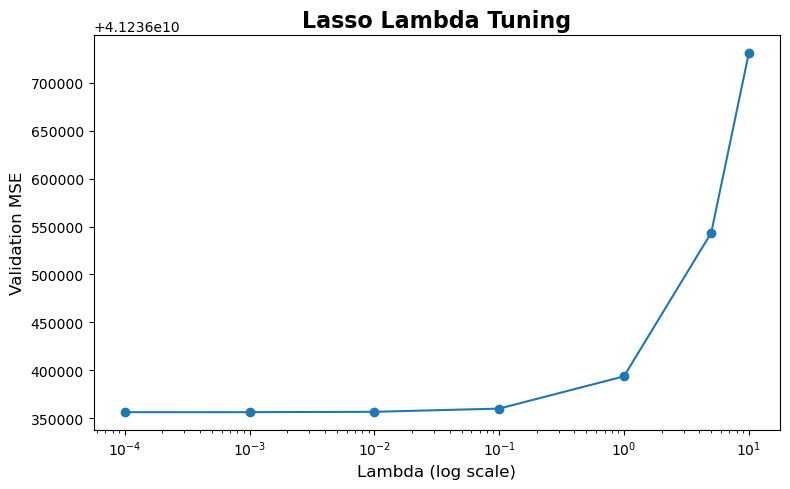

In [45]:
plt.figure(figsize=(8, 5))
plt.plot(lasso_results_df['lambda'], lasso_results_df['validation_mse'], marker='o')
plt.xscale('log')
plt.xlabel("Lambda (log scale)", fontsize=12)
plt.ylabel("Validation MSE", fontsize=12)
plt.title("Lasso Lambda Tuning", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Lasso convergence plot

In [46]:
fig_gd = px.line(
    x=range(len(final_lasso_model.loss_history)),
    y=final_lasso_model.loss_history,
    markers=True,
    labels={
        'x': 'Iterations (Epochs)',
        'y': 'Loss = MSE + λ × L1 Penalty'
    },
    title="Gradient Descent Convergence: Loss vs. Iterations<br>"
          "<sup>Lasso Regression (best λ selected on validation set)</sup>"
)
fig_gd.update_layout(height=600, width=1000, hovermode="x unified", template="plotly_white")
fig_gd.update_traces(line=dict(width=3, color="gray"))
fig_gd.show()

Lasso: Predicted vs Actual

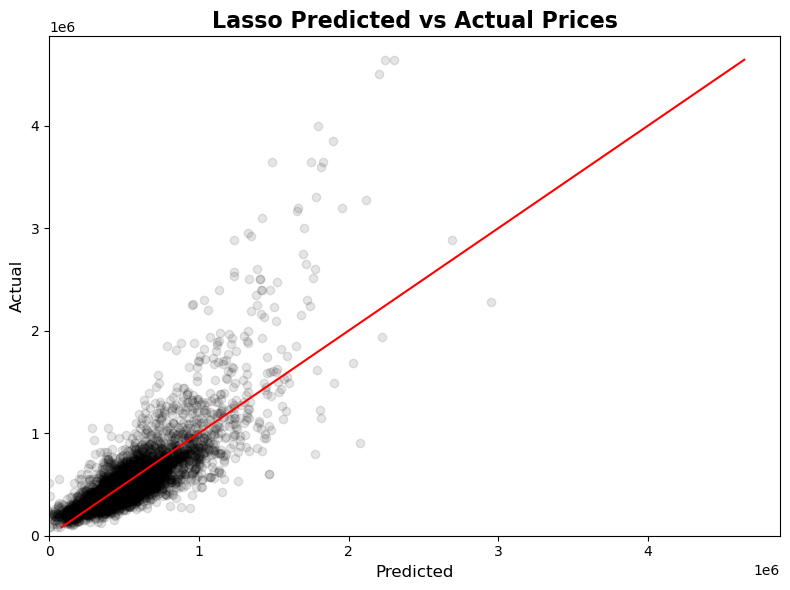

In [47]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_pred_lasso, y_test, alpha=0.1, color="black")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.xlim(0)
plt.ylim(0)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("Lasso Predicted vs Actual Prices", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Lasso coefficient table

In [48]:

lasso_coef_df = pd.DataFrame({
    'Feature':          selected_features,
    'Lasso Regression': final_lasso_model.B
})
coef_df = lasso_coef_df.copy()
coef_df['Abs_Coefficient'] = np.abs(coef_df['Lasso Regression'])
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False).head(15)

coef_melt = coef_df.melt(
    id_vars=['Feature', 'Abs_Coefficient'],
    value_vars=['Lasso Regression'],
    var_name='Model',
    value_name='Coefficient'
)


##  Residual Plots for the 3 Model Specifications

In [49]:
import plotly.graph_objects as go
import numpy as np

residuals_single = np.array(y_test) - np.array(y_pred)
residuals_ridge  = np.array(y_test) - np.array(y_pred_ridge)
residuals_lasso  = np.array(y_test) - np.array(y_test_pred_lasso)

trace_single = go.Scatter(
    x=list(y_pred), y=list(residuals_single),
    mode='markers', name='Single Predictor',
    opacity=0.7, marker=dict(size=5, color='blue')
)
trace_ridge = go.Scatter(
    x=list(y_pred_ridge), y=list(residuals_ridge),
    mode='markers', name='Ridge (Full Model)',
    opacity=0.7, marker=dict(size=5, color='green')
)
trace_lasso = go.Scatter(
    x=list(y_test_pred_lasso), y=list(residuals_lasso),
    mode='markers', name='Lasso Regression',
    opacity=0.7, marker=dict(size=5, color='black')
)

fig = go.Figure(data=[trace_single, trace_ridge, trace_lasso])

fig.add_hline(y=0, line_dash="dash", line_color="red", line_width=3)

fig.update_layout(
    updatemenus=[
        dict(
            type="dropdown",
            direction="down",
            x=0.1, y=1.15,
            showactive=True,
            buttons=[
                dict(label="All Models",
                     method="update",
                     args=[{"visible": [True, True, True]}]),
                dict(label="Single Predictor Only",
                     method="update",
                     args=[{"visible": [True, False, False]}]),
                dict(label="Ridge Only",
                     method="update",
                     args=[{"visible": [False, True, False]}]),
                dict(label="Lasso Only",
                     method="update",
                     args=[{"visible": [False, False, True]}]),
                dict(label="Single + Ridge",
                     method="update",
                     args=[{"visible": [True, True, False]}]),
                dict(label="Single + Lasso",
                     method="update",
                     args=[{"visible": [True, False, True]}]),
                dict(label="Ridge + Lasso",
                     method="update",
                     args=[{"visible": [False, True, True]}]),
            ]
        )
    ],
    title="Residual Plots for the 3 Model Specifications",
    xaxis_title="Predicted House Price",
    yaxis_title="Residuals (Actual Price - Predicted Price)",
    width=1000, height=650,
    template="plotly_white",
    legend_title="Model Specification",
    showlegend=True
)

fig.show()

## Coefficient Bar Chart Across Model Specifications

In [50]:

single_features = selected_features
single_coefs    = [b1 if f == 'sqft_living' else 0.0 for f in selected_features]

ridge_features  = list(X_train.columns)
ridge_coefs     = list(ridge_model.weights)

lasso_features  = selected_features
lasso_coefs     = list(final_lasso_model.B)

trace_single = go.Bar(
    x=['sqft_living'],
    y=[b1],
    name='Single Predictor',
    marker_color='blue',
    visible=True,
    width=0.3
)
trace_ridge = go.Bar(
    x=ridge_features,
    y=ridge_coefs,
    name='Ridge (Full Model)',
    marker_color='green',
    visible=False
)
trace_lasso = go.Bar(
    x=lasso_features,
    y=lasso_coefs,
    name='Lasso Regression',
    marker_color='black',
    visible=False
)

fig = go.Figure(data=[trace_single, trace_ridge, trace_lasso])

fig.update_layout(
    updatemenus=[
        dict(
            type='dropdown',
            x=0.1, y=1.15,
            showactive=True,
            buttons=[
                dict(label='Single Predictor',
                     method='update',
                     args=[{'visible': [True, False, False]},
                           {'title': 'Coefficients — Single Predictor'}]),
                dict(label='Ridge (Full Model)',
                     method='update',
                     args=[{'visible': [False, True, False]},
                           {'title': 'Coefficients — Ridge (Full Model)'}]),
                dict(label='Lasso Regression',
                     method='update',
                     args=[{'visible': [False, False, True]},
                           {'title': 'Coefficients — Lasso Regression'}]),
            ]
        )
    ],
    title='Coefficients — Single Predictor',
    xaxis_title='Features',
    yaxis_title='Coefficient Value (Beta)',
    legend_title='Model Specification',
    template='plotly_white',
    width=1100, height=650,
    xaxis_tickangle=45
)

fig.show()

#**Feature retention summary**
- Lasso did not remove any features (all 14 kept), meaning all
- selected variables contribute to predicting house prices.
- Lasso still improved the model by shrinking less important
- coefficients rather than zeroing them out entirely

In [51]:
removed_features = lasso_coef_df[np.abs(lasso_coef_df['Lasso Regression']) <= 1e-6]
kept_features    = lasso_coef_df[np.abs(lasso_coef_df['Lasso Regression']) >  1e-6]

print("Number of features kept by Lasso:",    len(kept_features))
print("Number of features removed by Lasso:", len(removed_features))
print("\nRemoved features:")
print(removed_features['Feature'].tolist())

Number of features kept by Lasso: 14
Number of features removed by Lasso: 0

Removed features:
[]


Gradient Descent convergence: Lasso vs Ridge

In [52]:
fig_compare = go.Figure()

fig_compare.add_trace(go.Scatter(
    x=list(range(len(final_lasso_model.loss_history))),
    y=final_lasso_model.loss_history,
    mode='lines+markers',
    name="Lasso (λ = " + str(best_lambda) + ")",
    line=dict(width=3)
))

fig_compare.add_trace(go.Scatter(
    x=list(range(len(ridge_model_for_best_lambda.loss_history))),
    y=ridge_model.loss_history,
    mode='lines+markers',
    name=f"Ridge (λ = {top_lambda})",
    line=dict(width=3)
))

fig_compare.update_layout(
    title="Gradient Descent Convergence: Lasso vs Ridge",
    height=600,
    xaxis_title="Iterations",
    yaxis_title="Loss"
)
fig_compare.show()